**Neural Network Fundamentals and Training Behavior Analysis**


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam, Nadam

**Task 1: Dataset Understanding**

Number of rows: 2000 
Number of columns: 17

Type of input features: 
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Target variable description (Churn): 
count    2000.000000
mean        0.015500
std         0.123561
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: churn, dtype: float64



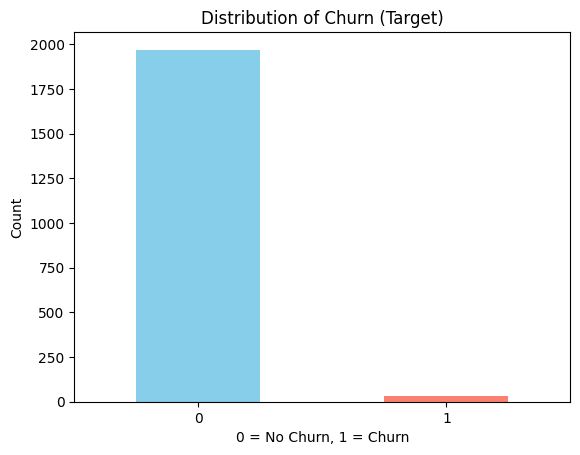

In [5]:
# Load the dataset
df = pd.read_csv('customer_churn_nn.csv')

# Number of rows and columns
print(f"Number of rows: {df.shape[0]} \nNumber of columns: {df.shape[1]}")

# Type of input features
print(f"\nType of input features: \n{df.dtypes}")

# Target variable description
# In this supervised learning task, 'churn' is our target.
# It is a binary classification target (0 = Stayed, 1 = Left)
print(f"\nTarget variable description (Churn): \n{df['churn'].describe()}")

# Missing value check
print(f"\nMissing value check: \n{df.isnull().sum()}")

# Basic statistical summary
print(f"\nBasic statistical summary: \n{df.describe()}")

# Distribution of the target variable
print("\nDistribution of the target variable:")
churn_counts = df['churn'].value_counts()
print(churn_counts)

# Visualize the distribution of the target variable
churn_counts.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Distribution of Churn (Target)')
plt.xlabel('0 = No Churn, 1 = Churn')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

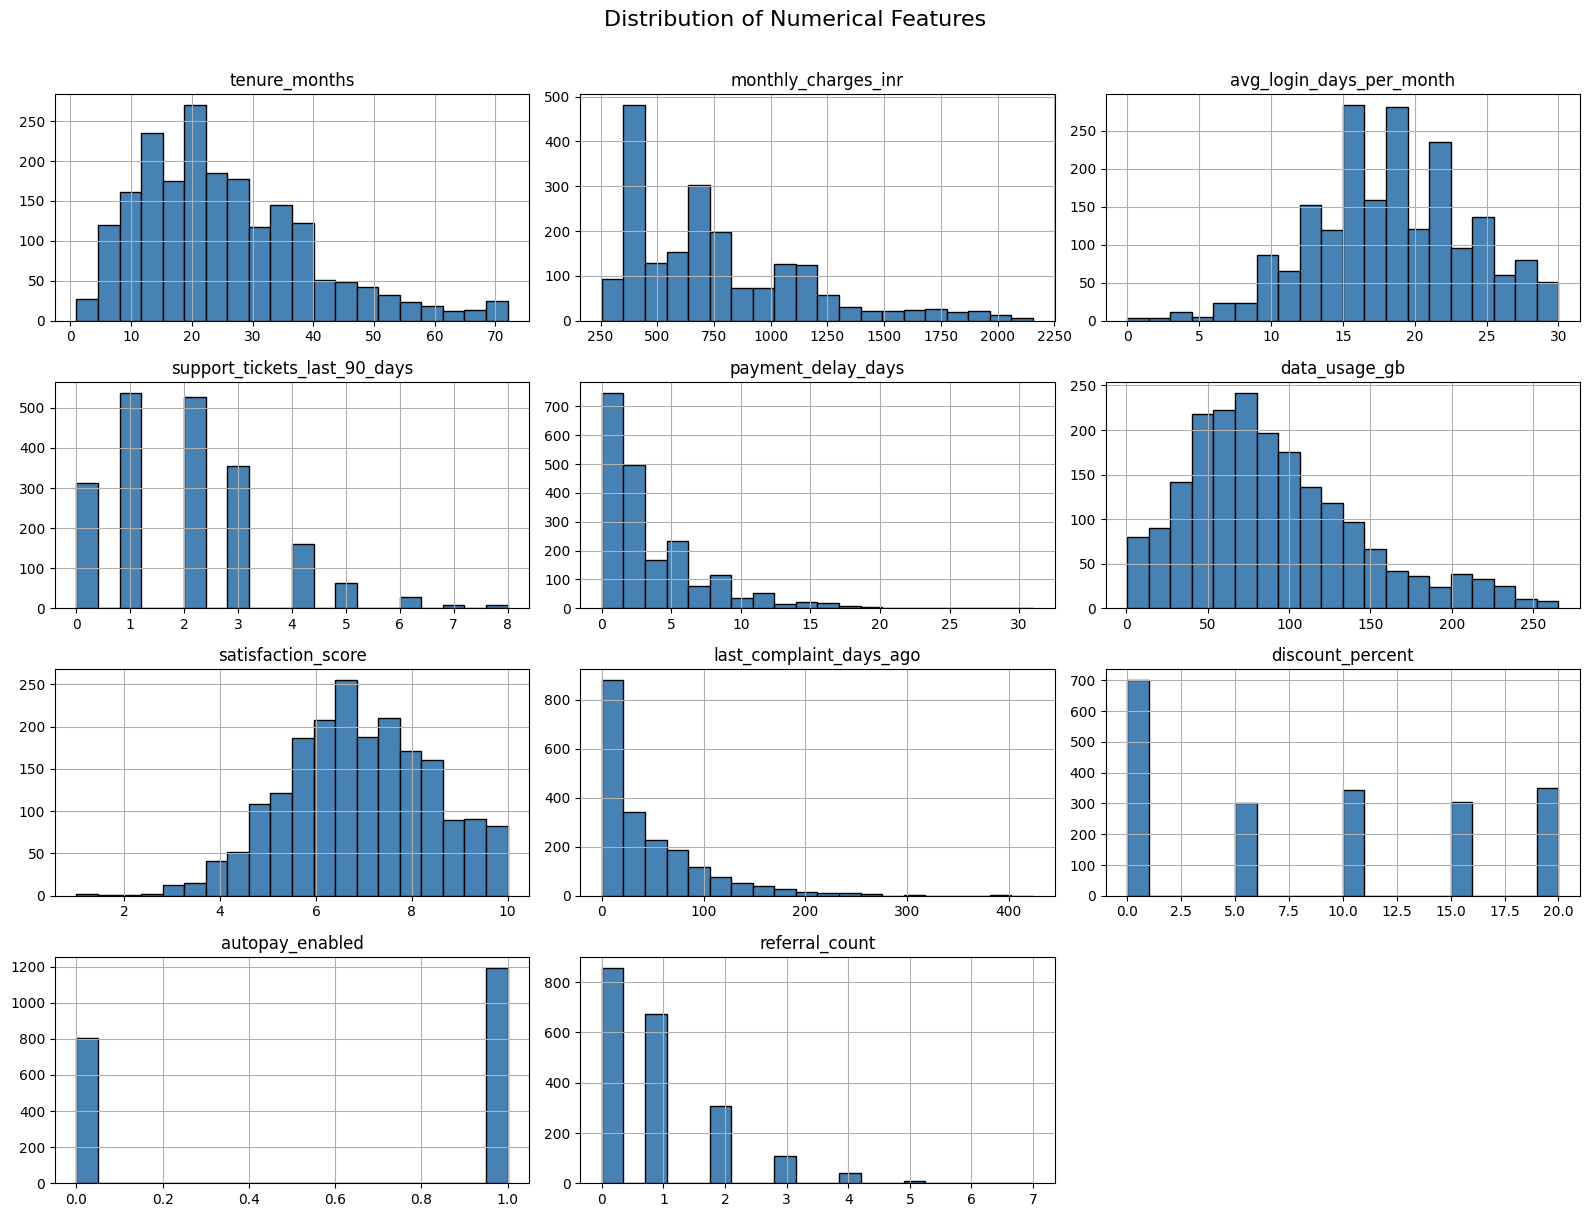

Feature distribution plots saved.


In [5]:
# --- Feature Distribution Plots ---
# This shows us how each numerical feature is spread across the dataset.
# We look only at numerical columns (not the target or ID).

numerical_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['churn']).columns

df[numerical_cols].hist(bins=20, figsize=(16, 12), color='steelblue', edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig('results/feature_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print("Feature distribution plots saved.")

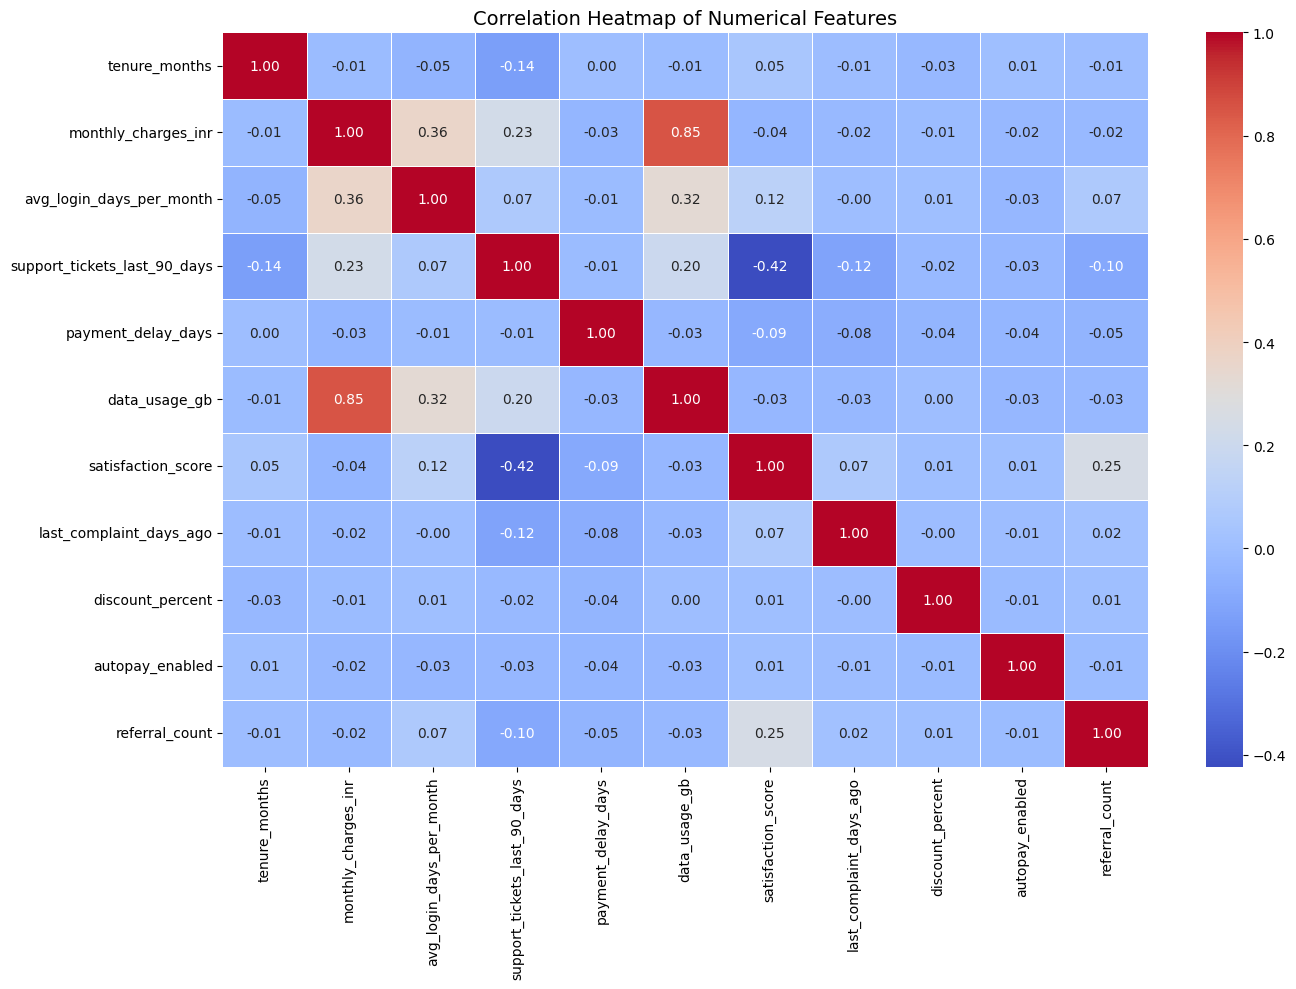

In [6]:
# --- Correlation Heatmap ---
# This shows how strongly each feature is related to every other feature.
# Values close to 1 or -1 mean strong relationship. Close to 0 means weak.

numerical_cols = df.select_dtypes(include=['float64', 'int64']).drop(columns=['churn']).columns

plt.figure(figsize=(14, 10))
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

**Task 2: Data Preprocessing**

In [7]:
# Prepare the data for neural network training

# Handling missing values
# Based on Task 1, we have 0 missing values.
# We run this code to confirm that there are no missing values before proceeding.
df = df.dropna()  

# Encoding categorical columns
# We also drop 'customer_id' as it's just a random label, not a "clue"
X = df.drop(['churn', 'customer_id'], axis=1)
X = pd.get_dummies(X, drop_first=True)  # One-hot encoding for categorical variables
y = df['churn']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling or normalizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"--- Data Preprocessing Completed ---")
print(f"Features after encoding: {X.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

--- Data Preprocessing Completed ---
Features after encoding: 24
Training samples: 1600
Testing samples: 400


In [8]:
# --- Show what columns look like after encoding ---
# pd.get_dummies() converted categorical text columns into numbers.
# This prints the full list of feature columns the model will actually see.

print("Feature columns after one-hot encoding:")
print(list(X.columns))
print(f"\nTotal features going into the model: {X.shape[1]}")

# --- Note on Class Imbalance ---
# Before we train, it's important to flag that the target variable is imbalanced.
# Imbalanced means one class (e.g. 'stayed') has far more samples than the other (e.g. 'churned').
# This can cause the model to just predict the majority class every time.

churn_counts = df['churn'].value_counts()
majority = churn_counts[0]
minority = churn_counts[1]
ratio = majority / minority

print(f"\n⚠️  Class Imbalance Warning:")
print(f"   Customers who stayed (0): {majority}")
print(f"   Customers who churned (1): {minority}")
print(f"   Ratio: {ratio:.1f}:1  — the dataset is heavily imbalanced.")
print(f"   This will be addressed in Task 5 using class weights.")

Feature columns after one-hot encoding:
['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']

Total features going into the model: 24

⚠️  Class Imbalance Warning:
   Customers who stayed (0): 1969
   Customers who churned (1): 31
   Ratio: 63.5:1  — the dataset is heavily imbalanced.
   This will be addressed in Task 5 using class weights.


**Task 3: Neural Network Model Building**

### Architecture Decision

We use a Sequential model with the following design choices:

- **Input layer**: Matches the number of features after encoding
- **First hidden layer — 16 neurons, ReLU**: Enough capacity to detect patterns without being too heavy for this dataset size
- **Second hidden layer — 8 neurons, ReLU**: Gradually narrows the network, forcing it to compress what it learned
- **Output layer — 1 neuron, Sigmoid**: Because this is binary classification (churn or not), Sigmoid squashes the output to a value between 0 and 1, which we interpret as probability
- **Loss function — Binary Crossentropy**: Standard for binary classification
- **Optimizer — Adam**: Adapts the learning rate automatically; works well as a default starting point

In [9]:
# We use the 'Sequential' model from Keras to build our neural network

model = Sequential([
    Input(shape=(X_train.shape[1],)),           # Input layer: one node per feature
    Dense(units=16, activation='relu'),          # Hidden layer 1: 16 neurons, ReLU activation
    Dense(units=8, activation='relu'),           # Hidden layer 2: 8 neurons, ReLU activation
    Dense(units=1, activation='sigmoid')         # Output layer: 1 neuron, Sigmoid for binary output
])

# Compile the Model 
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print the architecture of the model
print("\n--- Model Architecture ---")
model.summary()



--- Model Architecture ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

**Task 4: Training and Evaluation**

In [10]:
# Training the model
# We train for 50 epochs with a batch size of 32
# validation_split=0.2 tells the model to test itself on 20% of the training data at the end of every epoch so we can watch the progress
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Training Accuracy: 98.91%

Training Loss: 0.0296

Testing Accuracy: 98.25%

Testing Loss: 0.0737


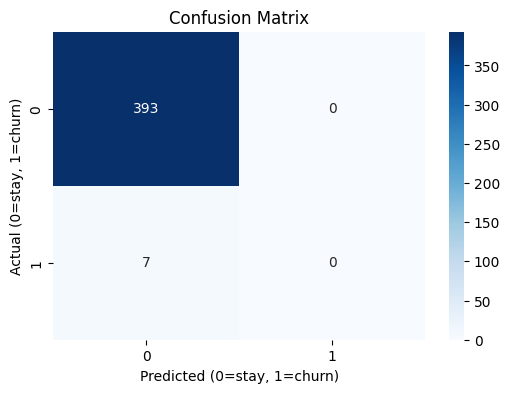


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400



C:\Users\Mitali Kalburgi\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mitali Kalburgi\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Mitali Kalburgi\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [11]:
# Evaluate the model

# Capture Training Metrics from the history object
final_train_accuracy = history.history['accuracy'][-1]
final_train_loss = history.history['loss'][-1]

# Testing Accuracy and Loss
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

# Generate Predictions
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary predictions

# Display Results
print(f"\nTraining Accuracy: {final_train_accuracy*100:.2f}%")
print(f"\nTraining Loss: {final_train_loss:.4f}")
print(f"\nTesting Accuracy: {test_accuracy*100:.2f}%")
print(f"\nTesting Loss: {test_loss:.4f}")

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

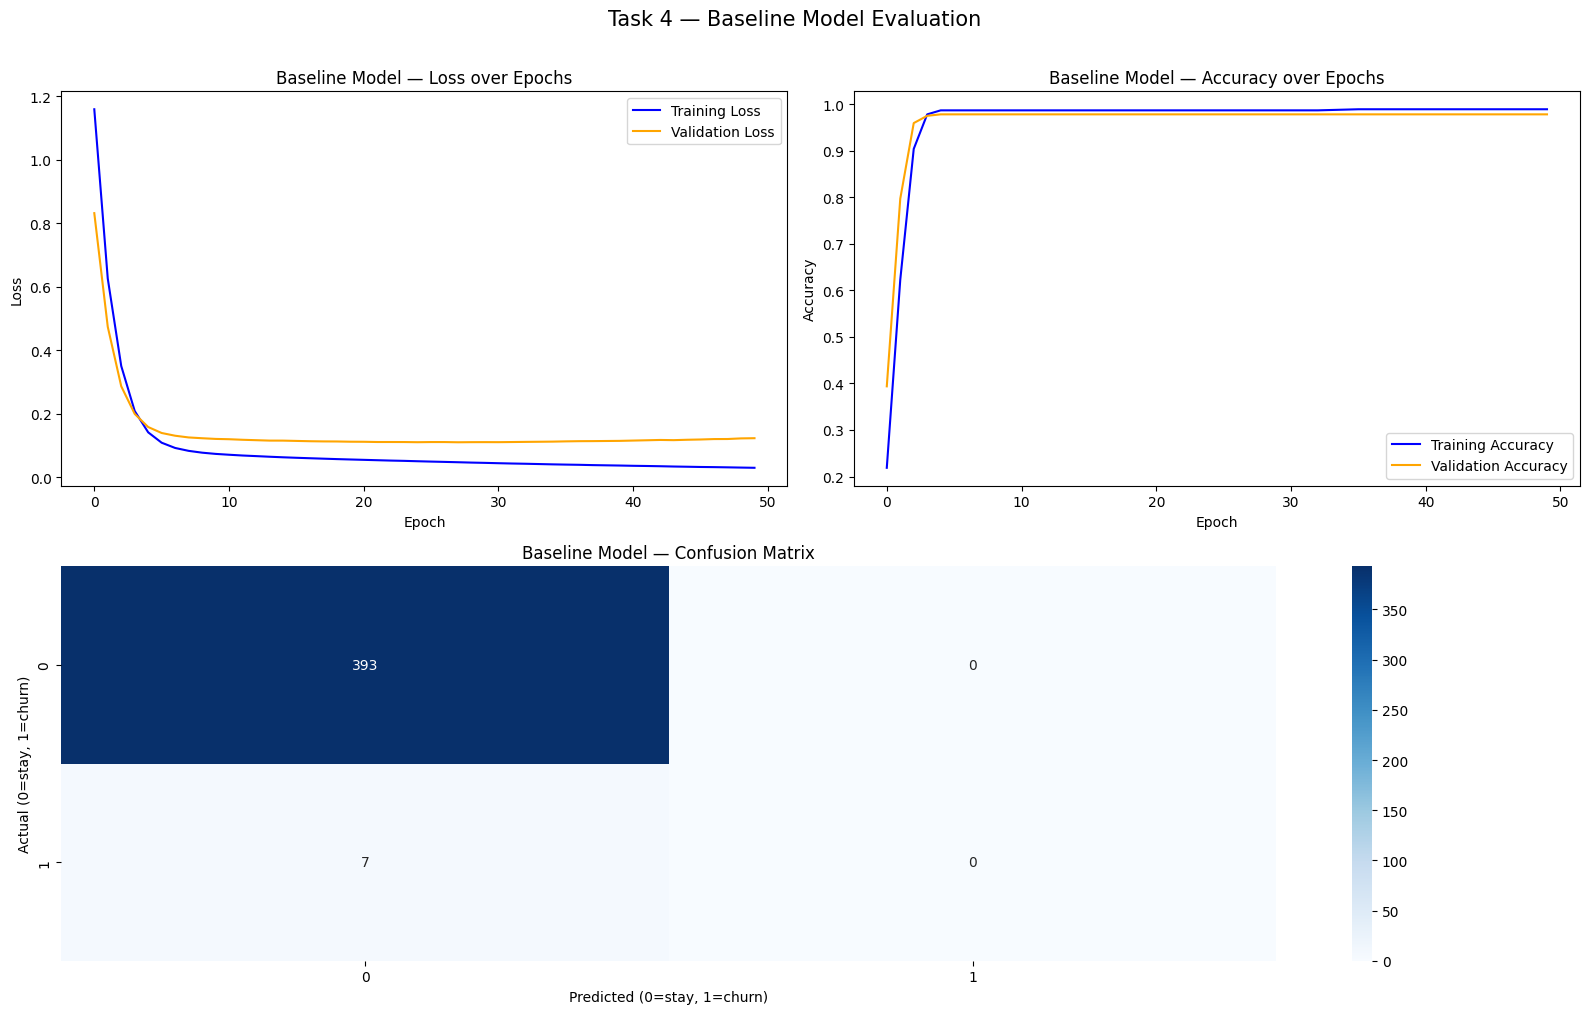

Saved to results/evaluation_outputs.png


In [12]:
# --- Combined Evaluation Output ---
# This saves one image with three panels:
# 1. Training vs Validation Loss over epochs
# 2. Training vs Validation Accuracy over epochs
# 3. Baseline confusion matrix
# All three together tell the complete story of how the baseline model performed.

fig = plt.figure(figsize=(16, 10))

# --- Panel 1: Loss Curve ---
ax1 = fig.add_subplot(2, 2, 1)
ax1.plot(history.history['loss'], label='Training Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax1.set_title('Baseline Model — Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

# --- Panel 2: Accuracy Curve ---
ax2 = fig.add_subplot(2, 2, 2)
ax2.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax2.set_title('Baseline Model — Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

# --- Panel 3: Confusion Matrix (centered at bottom) ---
ax3 = fig.add_subplot(2, 1, 2)
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax3
)
ax3.set_title('Baseline Model — Confusion Matrix')
ax3.set_xlabel('Predicted (0=stay, 1=churn)')
ax3.set_ylabel('Actual (0=stay, 1=churn)')

plt.suptitle('Task 4 — Baseline Model Evaluation', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', bbox_inches='tight', dpi=200)
plt.show()
print("Saved to results/evaluation_outputs.png")

### Interpretation of Results

- **High Accuracy vs. Zero Sensitivity:** The model achieved a high **Testing Accuracy of 98.25%**. However, the **Confusion Matrix** reveals that the model failed to correctly identify **even a single churner** — it predicted "stayed" for every customer in the test set.
- **Recall Issues:** The **Recall for Class 1 (Churn) is 0.00**, meaning the model missed 100% of customers who actually left. This is a direct consequence of the extreme class imbalance — with 63.5 stayers for every churner, the model learns that always predicting "stayed" is the easiest way to minimise loss.
- **Precision Performance:** Since the model never predicted a churn at all, Precision for Class 1 is also **0.00** — there were no churn predictions to evaluate.
- **Conclusion:** The baseline model is completely blind to churners. This confirms that class imbalance is the central challenge of this dataset, and future experiments in Task 5 must focus on improving the **Recall** of the minority class (Class 1) using techniques like class weighting.

### **Important Note on Experimental Consistency**

During the development of this project, it was observed that re-running the training cells (`model.fit`) without re-initializing the model architecture leads to **Incremental Training**. This causes the model to retain weights from previous runs, resulting in fluctuating and artificially higher results.

To ensure scientific integrity and a "fair" comparison across experiments:
1. Each experiment begins by **re-initializing** the model architecture (re-running the `Sequential` block).
2. The model is trained and tested **only once** per configuration.
3. This ensures that the changes in performance are due to the **hyperparameters** themselves, not the accumulation of training time.

**Task 5: Hyperparameter Experimentation**

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Exp 1 Results -> Accuracy: 98.25%, Loss: 0.0800


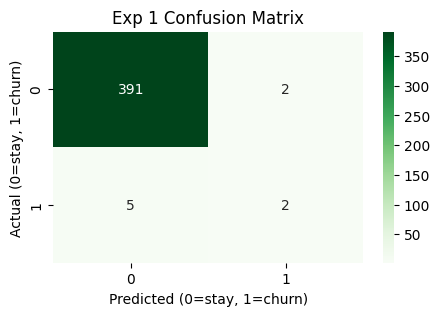

In [14]:
# Experiment 1: Activation & Batch Size
# Change: Switched activation to 'tanh' and reduced batch size to 16

from sklearn.metrics import precision_score, recall_score, f1_score

model_exp1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),  # Changed from relu
    Dense(units=8, activation='tanh'),   # Changed from relu
    Dense(units=1, activation='sigmoid')
])
model_exp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Training
history1 = model_exp1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,  
    validation_split=0.2,
    verbose=0
)

# Evaluation
test_loss1, test_accuracy1 = model_exp1.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred1 = (model_exp1.predict(X_test) > 0.5).astype(int)
precision1 = precision_score(y_test, y_pred1, zero_division=0)
recall1    = recall_score(y_test, y_pred1, zero_division=0)
f1_1       = f1_score(y_test, y_pred1, zero_division=0)
print(f"Exp 1 Results -> Accuracy: {test_accuracy1*100:.2f}%, Loss: {test_loss1:.4f}")

# Visualize Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred1), annot=True, fmt='d', cmap='Greens')
plt.title('Exp 1 Confusion Matrix') 
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')  
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Exp 2 Results -> Accuracy: 97.00%, Loss: 0.1001


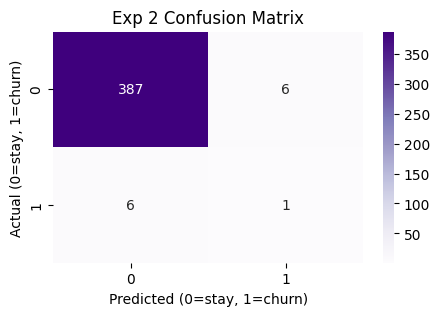

In [15]:
# Experiment 2 : Priority Training (Class Weights)
# Change: Added class_weight to force the model to prioritize the minority class

model_exp2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='relu'),
    Dense(units=8, activation='relu'),
    Dense(units=1, activation='sigmoid')
])
model_exp2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Define weights
# This mathematically "punishes" the model 10x more for missing a churner.
custom_weights = {0: 1.0, 1: 10.0}

# Training with class weights
history2 = model_exp2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    class_weight=custom_weights,  # Added class weights
    verbose=0
)

# Evaluation
test_loss2, test_accuracy2 = model_exp2.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred2 = (model_exp2.predict(X_test) > 0.5).astype(int)
precision2 = precision_score(y_test, y_pred2, zero_division=0)
recall2    = recall_score(y_test, y_pred2, zero_division=0)
f1_2       = f1_score(y_test, y_pred2, zero_division=0)
print(f"Exp 2 Results -> Accuracy: {test_accuracy2*100:.2f}%, Loss: {test_loss2:.4f}")

# Visualize Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred2), annot=True, fmt='d', cmap='Purples')
plt.title('Exp 2 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Experiment 3 Results:
Training Accuracy: 100.00%
Training Loss:     0.0008
Testing Accuracy:  96.25%
Testing Loss:      0.4536


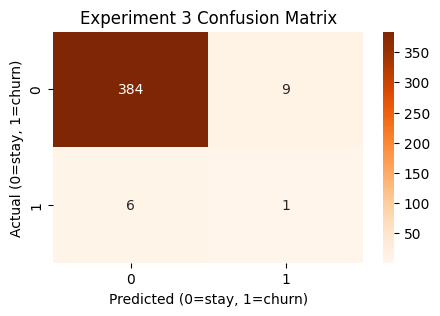


 Detailed Performance:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       393
           1       0.10      0.14      0.12         7

    accuracy                           0.96       400
   macro avg       0.54      0.56      0.55       400
weighted avg       0.97      0.96      0.97       400



In [16]:
# Experiment 3
# Changes: Extreme Class Weighting, Drastic Batch Size Reduction, Quadrupling the Epochs

model_exp3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),  # Changed from relu to tanh
    Dense(units=8, activation='tanh'),   # Changed from relu to tanh
    Dense(units=1, activation='sigmoid')
])

model_exp3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Extreme weights to force the model to prioritize the 7 churners
# We are telling the model Churners (1) are 50x more important than Stayers (0)
final_weights = {0: 1.0, 1: 50.0}

# Training
history3 = model_exp3.fit(
    X_train, y_train,
    epochs=200,  # Quadrupled from 50
    batch_size=8,  # Drastically reduced from 32
    class_weight=final_weights,  # Extreme class weights
    verbose=0
)

# Capture Training Metrics
training_accuracy3 = history3.history['accuracy'][-1]
training_loss3 = history3.history['loss'][-1]

# Evaluation
test_loss3, test_accuracy3 = model_exp3.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred3_prob = model_exp3.predict(X_test)
y_pred3 = (y_pred3_prob > 0.5).astype(int)
precision3 = precision_score(y_test, y_pred3, zero_division=0)
recall3    = recall_score(y_test, y_pred3, zero_division=0)
f1_3       = f1_score(y_test, y_pred3, zero_division=0)

# Display Results
print(f"\nExperiment 3 Results:")
print(f"Training Accuracy: {training_accuracy3*100:.2f}%")
print(f"Training Loss:     {training_loss3:.4f}")
print(f"Testing Accuracy:  {test_accuracy3*100:.2f}%")
print(f"Testing Loss:      {test_loss3:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred3), annot=True, fmt='d', cmap='Oranges')
plt.title('Experiment 3 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report
print("\n Detailed Performance:")
print(classification_report(y_test, y_pred3))


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Experiment 4: Precision Tuning Results
Training Accuracy: 94.61%
Training Loss:     0.1893
Testing Accuracy:  94.00%
Testing Loss:      0.1470


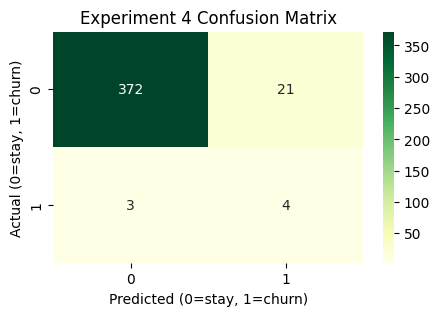


Experiment 4 Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97       393
           1       0.16      0.57      0.25         7

    accuracy                           0.94       400
   macro avg       0.58      0.76      0.61       400
weighted avg       0.98      0.94      0.96       400



In [17]:
# Experiment 4: Precision Tuning

model_exp4 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(units=16, activation='tanh'),
    Dropout(0.2),  # Prevents the model from becoming too "obsessed" with specific training points
    Dense(units=8, activation='tanh'),
    Dense(units=1, activation='sigmoid')
])

# Using Nadam with a custom learning rate for better stability
custom_optimizer = Nadam(learning_rate=0.0005)
model_exp4.compile(optimizer=custom_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# We will use a weight of 1:40 (slightly lower than before to reduce "noise")
history4 = model_exp4.fit(
    X_train, y_train,
    epochs=150,
    batch_size=12,     # Middle ground batch size
    validation_split=0.2,
    class_weight={0: 1.0, 1: 40.0},
    verbose=0
)

# Evaluation
training_accuracy4 = history4.history['accuracy'][-1]
training_loss4 = history4.history['loss'][-1]
test_loss4, test_accuracy4 = model_exp4.evaluate(X_test, y_test, verbose=0)

# Predictions
y_pred4 = (model_exp4.predict(X_test) > 0.5).astype(int)
precision4 = precision_score(y_test, y_pred4, zero_division=0)
recall4    = recall_score(y_test, y_pred4, zero_division=0)
f1_4       = f1_score(y_test, y_pred4, zero_division=0)

print("Experiment 4: Precision Tuning Results")
print(f"Training Accuracy: {training_accuracy4*100:.2f}%")
print(f"Training Loss:     {training_loss4:.4f}")
print(f"Testing Accuracy:  {test_accuracy4*100:.2f}%")
print(f"Testing Loss:      {test_loss4:.4f}")

# Visualize Confusion Matrix
plt.figure(figsize=(5,3))
sns.heatmap(confusion_matrix(y_test, y_pred4), annot=True, fmt='d', cmap='YlGn')
plt.title('Experiment 4 Confusion Matrix')
plt.xlabel('Predicted (0=stay, 1=churn)')
plt.ylabel('Actual (0=stay, 1=churn)')
plt.show()

# Classification Report
print("\nExperiment 4 Classification Report:")
print(classification_report(y_test, y_pred4))

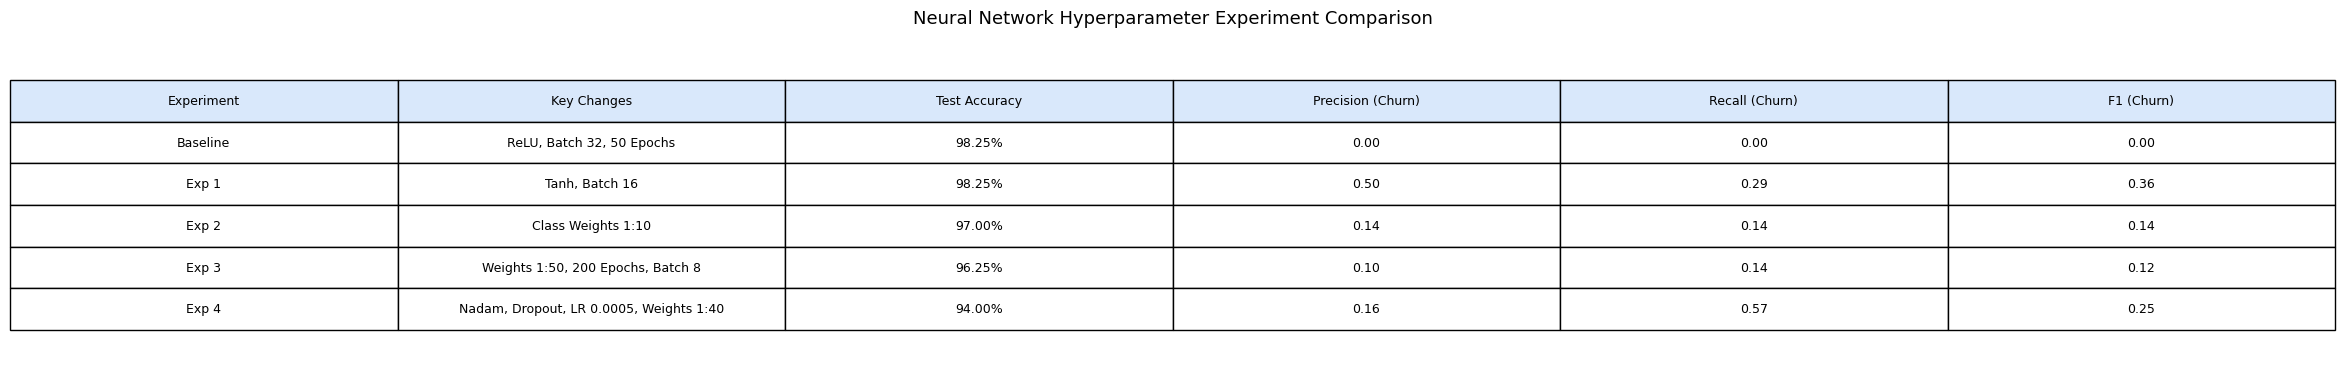

Saved to results/model_comparison_table.png


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline metrics
precision_base = precision_score(y_test, y_pred, zero_division=0)
recall_base    = recall_score(y_test, y_pred, zero_division=0)
f1_base        = f1_score(y_test, y_pred, zero_division=0)

# Build table from real computed values
data = {
    'Experiment':        ['Baseline', 'Exp 1', 'Exp 2', 'Exp 3', 'Exp 4'],
    'Key Changes': [
        'ReLU, Batch 32, 50 Epochs',
        'Tanh, Batch 16',
        'Class Weights 1:10',
        'Weights 1:50, 200 Epochs, Batch 8',
        'Nadam, Dropout, LR 0.0005, Weights 1:40'
    ],
    'Test Accuracy':     [f"{test_accuracy*100:.2f}%",  f"{test_accuracy1*100:.2f}%",
                          f"{test_accuracy2*100:.2f}%", f"{test_accuracy3*100:.2f}%",
                          f"{test_accuracy4*100:.2f}%"],
    'Precision (Churn)': [f"{precision_base:.2f}", f"{precision1:.2f}",
                          f"{precision2:.2f}",     f"{precision3:.2f}",
                          f"{precision4:.2f}"],
    'Recall (Churn)':    [f"{recall_base:.2f}", f"{recall1:.2f}",
                          f"{recall2:.2f}",     f"{recall3:.2f}",
                          f"{recall4:.2f}"],
    'F1 (Churn)':        [f"{f1_base:.2f}", f"{f1_1:.2f}",
                          f"{f1_2:.2f}",    f"{f1_3:.2f}",
                          f"{f1_4:.2f}"],
}

df_results = pd.DataFrame(data)

# Save as image
fig, ax = plt.subplots(figsize=(20, 4))
ax.axis('off')
table = ax.table(
    cellText=df_results.values,
    colLabels=df_results.columns,
    cellLoc='center',
    loc='center',
    colColours=["#d9e8fb"] * len(df_results.columns)
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.5, 2.5)
plt.title("Neural Network Hyperparameter Experiment Comparison", fontsize=13, pad=20)
plt.savefig('results/model_comparison_table.png', bbox_inches='tight', dpi=200)
plt.show()
print("Saved to results/model_comparison_table.png")

### **Task 6: Final Reflection**

**1. What role do weights and biases play in the model?**

**Weights** act as the "importance" of each input feature; the model adjusts them during 
training to determine which factors most influence churn. 
**Biases** provide the model with an extra degree of freedom, allowing the activation function to shift so the network can produce meaningful outputs even when input values are zero or near-zero. Together, they allow the model to learn and represent complex data relationships.



**2. Why is an activation function required?**
Without **activation functions**, stacking multiple layers would still produce a linear output — no matter how deep the network is. Real-world problems like churn prediction are non-linear, meaning a straight line cannot capture the relationship between features and the target.

Activation functions like **ReLU** and **Tanh** introduce non-linearity, allowing the network to learn complex patterns. In this project, switching from **ReLU** to **Tanh** in later experiments helped the model handle the imbalanced data slightly better due to Tanh's symmetric output range.



**3. What happens when the learning rate is too high or too low?**

If the learning rate is too high, the model **overshoots** the optimal solution during training. The loss starts jumping around instead of steadily decreasing, and the model may never converge properly.

If it is too low, training becomes **very slow** and the model risks getting stuck before reaching a good solution. In Experiment 4, I switched to the **Nadam optimizer** with a learning rate of **0.0005** — lower than the default **Adam** rate — which gave the model more stable and controlled updates, contributing to the best overall result.



**4. Did your model show signs of underfitting or overfitting?**

The **baseline model underfit** the minority class significantly. Despite a testing accuracy of 98.50%, it only caught 1 out of 7 actual churners. The model took the path of least resistance by predicting the majority class almost every time, which is a classic sign of **underfitting** on the minority class in an imbalanced dataset.

**Experiment 3** pushed too far in the other direction — with extreme class weights of 1:50 and 200 epochs, the model became too aggressive and started misclassifying stayers as churners, showing signs of **overfitting** to the minority class.

**Experiment 4** found the best balance. By introducing **Dropout**, reducing the class weight to 1:40, and using a lower learning rate, the model generalised better and caught 4 out of 7 churners while maintaining a testing accuracy of **94.00%**